In [10]:
import numpy as np 
import matplotlib.pyplot as plt

In [11]:
GAMMA=0.9
ALL_POSSIBLE_ACTIONS=('U','D','L','R')

In [12]:
class Grid:
    def __init__(self,rows,cols,start):
        self.rows=rows
        self.cols=cols
        self.i=start[0]
        self.j=start[1]
    
    def set(self,rewards,actions):
        self.rewards=rewards
        self.actions=actions
    
    def set_state(self,s):
        self.i=s[0]
        self.j=s[1]
    
    def current_state(self):
        return (self.i,self.j)

    def is_terminal(self,s):
        return s not in self.actions

    def get_next_state(self,s,a):
        i,j=s[0],s[1]
        if a in self.actions[i,j]:
            if a=='U':
                i -=1
            if a=='D':
                i +=1
            if a=='L':
                j -=1
            if a=='R':
                j +=1
        return i,j

    def move (self,action):
        if action in self.actions[(self.i,self.j)]:
            if action =='U':
                self.i -=1
            if action =='D':
                self.i +=1
            if action =='R':
                self.j +=1
            if action =='L':
                self.j -=1
            
        return self.rewards.get((self.i,self.j),0)

    def undo_move (self,action):
        if action =='U':
            self.i +=1
        if action =='D':
            self.i -=1
        if action =='R':
            self.j -=1
        if action =='L':
            self.j +=1
        assert(self.current_state() in self.all_stats())

    def game_over (self):
        return (self.i,self.j) not in self.actions

    def all_states(self):
        return set(self.actions.keys()) | set (self.rewards.keys())

In [13]:
def print_values(V,g):
    for i in range (g.rows):
        print("--------------------------")
        for j in range(g.cols):
            v=V.get((i,j),0)
            if v >=0:
                print(" %.2f |"% v,end="")
            else:
                print("%.2f |" %v,end="")
        print("")
        
        
def print_policy(P,g):
    for i in range(g.rows):
        print("----------------------------")
        for j in range(g.cols):
            a=P.get((i,j),' ')
            print(" %s |" %a,end="")
        print("")
    


In [14]:
def standard_grid():
    g=Grid(3,4,(2,0))
    rewards={(0,3):1,(1,3):-1}

    actions={
        (0,0):('D','R'),
        (0,1):('L','R'),
        (0,2):('L','R','D'),
        (1,0):('U','D'),
        (1,2):('R','U','D'),
        (2,0):('U','R'),
        (2,1):('L','R'),
        (2,2):('L','R','U'),
        (2,3):('L','U')
    }
    
    
    g.set(rewards,actions)
    return g
    

In [15]:
def play_game(grid,policy,max_steps=20):
    
    start_states=list(grid.actions.keys())
    start_idx=np.random.choice(len(start_states))
    grid.set_state(start_states[start_idx])
    
    s=grid.current_state()
    a= np.random.choice(ALL_POSSIBLE_ACTIONS)
    
    states=[s]
    actions=[a]
    rewards=[0]
    
    for _ in range(max_steps):
        r=grid.move(a)
        s=grid.current_state()
        
        rewards.append(r)
        states.append(s)
        
        if grid.game_over():
            break
        else:
            a=policy[s]
            actions.append(a)
            
    return states,actions,rewards

def max_dict(d):
    max_val=max(d.values())
    
    max_keys=[key for key , val in d.items() if val== max_val]
    
    return np.random.choice(max_keys) , max_val
    

rewards:
--------------------------
 0.00 | 0.00 | 0.00 | 1.00 |
--------------------------
 0.00 | 0.00 | 0.00 |-1.00 |
--------------------------
 0.00 | 0.00 | 0.00 | 0.00 |
0
1000
2000
3000
4000
5000
6000
7000
8000
9000


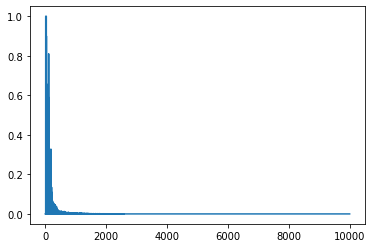

final policy:
----------------------------
 R | R | R |   |
----------------------------
 U |   | U |   |
----------------------------
 R | R | U | L |
final values:
--------------------------
 0.81 | 0.90 | 1.00 | 0.00 |
--------------------------
 0.73 | 0.00 | 0.90 | 0.00 |
--------------------------
 0.66 | 0.73 | 0.81 | 0.73 |


In [18]:
if __name__ =='__main__':
    grid=standard_grid()
    
    print('rewards:')
    print_values(grid.rewards,grid)
    
    policy={}
    for s in grid.actions.keys():
        policy[s]=np.random.choice(ALL_POSSIBLE_ACTIONS)
        
    Q={}
    sample_counts={}
    states=grid.all_states()
    for s in states:
        if s in grid.actions:
            Q[s]={}
            sample_counts[s]={}
            for a in ALL_POSSIBLE_ACTIONS:
                Q[s][a]=0
                sample_counts[s][a]=0
                 
        else:
            pass
         
    deltas=[]
    for it in range(10000):
        if it %1000==0:
            print(it)    
        biggest_change=0
        states,actions,rewards=play_game(grid,policy)
        states_actions=list(zip(states,actions))
             
        T=len(states)
        G=0
        for t in range(T-2,-1,-1):
            s=states[t]
            a=actions[t]
            
            G=rewards[t+1] +GAMMA*G
                 
            if (s,a) not in states_actions[:t]:
                old_q=Q[s][a]
                sample_counts[s][a] +=1
                lr =1/sample_counts[s][a]
                Q[s][a]=old_q +lr*(G-old_q)
                     
                policy[s]=max_dict(Q[s])[0]
                     
                biggest_change=max(biggest_change,np.abs(old_q-Q[s][a]))
                     
        deltas.append(biggest_change)
             
    plt.plot(deltas)
    plt.show()
         
    print('final policy:')
    print_policy(policy,grid)
         
    V={}
    for s , Qs in Q.items():
        V[s]=max_dict(Q[s])[1]
             
    print('final values:')
    print_values(V,grid)
                     
            
            